# Study 253 -- Wiki-Views
## For the quants: surge signal, HAC tests, bootstrap CI, sub-period nulls, costs

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wikipedia_views import data, strategy as st

CACHE_PATH = data.RETURNS_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices = data.fetch_returns(fetch=False, cache_path=CACHE_PATH)
    views = data.wiki_views_panel(n_months=prices.shape[0])
    views, prices = data.align_panels(views, prices)
    TAPE = "cached Yahoo monthly tape"
else:
    # Deterministic offline best-effort proxy: curated views + views-INDEPENDENT prices
    views, prices = data.best_effort_real_tape(n_months=120, seed=data.SEED)
    TAPE = "offline best-effort proxy (curated views, views-independent prices)"

sur = st.attention_surge(views, smooth=1)
res = st.decile_returns(sur, prices, q=0.20)
spread = res["spread"].dropna()
low_xret = (res["low"] - res["market"]).dropna()
print(f"Tape: {TAPE}")
print(f"Panel: {prices.shape[0]} months x {prices.shape[1]} tickers")
print(f"Portfolio months: {len(res)}  |  ~{res['n_low'].mean():.0f} names per leg")


Tape: offline best-effort proxy (curated views, views-independent prices)
Panel: 120 months x 30 tickers
Portfolio months: 118  |  ~6 names per leg


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 118, 'n_leg': 6, 'n_tickers': 30, 'low_ann': 14.11, 'low_t': 2.44, 'high_ann': 15.33, 'high_t': 2.91, 'market_ann': 14.52, 'spread_ann': -1.22, 'spread_bps': -10.2, 'spread_t': -0.31, 'spread_hit': 0.483, 'low_xret_ann': -0.41, 'low_xret_t': -0.14, 'boot_lo': -0.726, 'boot_hi': 0.542, 'boot_frac_neg': 63, 'sub_2017_mean': -2.48, 'sub_2017_t': -0.34, 'sub_2017_n': 36, 'sub_2020_mean': 0.29, 'sub_2020_t': 0.04, 'sub_2020_n': 36, 'sub_2023_mean': -0.26, 'sub_2023_t': -0.03, 'sub_2023_n': 35, 'turnover': 89.08, 'drag_bps': 35.6, 'net_spread_bps': -45.8, 'net_spread_t': -1.39, 'rand_bps': -3.6, 'ctrl_premium': 2.0, 'ctrl_spread_ann': 62.02, 'ctrl_spread_t': 17.03, 'null_spread_ann': -4.38, 'null_spread_t': -1.21}


## Positive control: the engine finds attention-reversal when it is planted

> 💡 **In plain words.** Before trusting a null on real data, prove the machinery can
> see a signal that is *definitely* there. We plant a known attention-reversal premium in
> a synthetic panel and confirm the quintile sort lights up.


In [3]:
# Synthetic positive control: planted reversal premium=0.02 -> strong positive spread
price_syn, views_syn, truth = data.synthetic_attention_panel(n_firms=30, n_months=120, premium=0.02, seed=253)
sur_syn = st.attention_surge(views_syn)
res_syn = st.decile_returns(sur_syn, price_syn, q=0.20)
s_syn = st.summarize(res_syn["spread"].dropna())
print(f"Positive control (premium=0.02):")
print(f"  Spread = {s_syn['mean']*1200:+.2f}%/yr  HAC t = {s_syn['tstat']:+.2f}  n = {s_syn['n']}")

# Null control: premium=0.0
price0, views0, _ = data.synthetic_attention_panel(n_firms=30, n_months=120, premium=0.0, seed=253)
res0 = st.decile_returns(st.attention_surge(views0), price0, q=0.20)
s0 = st.summarize(res0["spread"].dropna())
print(f"\nNull control (premium=0.0):")
print(f"  Spread = {s0['mean']*1200:+.2f}%/yr  HAC t = {s0['tstat']:+.2f}  n = {s0['n']}")
print("  -> Engine reads strong on planted reversal, ~zero on the null. The machinery is honest.")


Positive control (premium=0.02):
  Spread = +62.02%/yr  HAC t = +17.03  n = 118



Null control (premium=0.0):
  Spread = -4.38%/yr  HAC t = -1.21  n = 118
  -> Engine reads strong on planted reversal, ~zero on the null. The machinery is honest.


## Primary specification: HAC t and bootstrap Sharpe CI on the real-ish tape

In [4]:
s_spread = st.summarize(spread)
s_low    = st.summarize(res["low"].dropna())
s_high   = st.summarize(res["high"].dropna())
s_market = st.summarize(res["market"].dropna())

print("=== Low-minus-high surge quintile, 1-month hold ===")
print(f"Portfolio months: {len(res)}   avg names/leg: {res['n_low'].mean():.0f}")
print()
print(f"LOW  (drought, long) : {s_low['mean']*1200:+.2f}%/yr  HAC t={s_low['tstat']:+.2f}")
print(f"HIGH (surge, short)  : {s_high['mean']*1200:+.2f}%/yr  HAC t={s_high['tstat']:+.2f}")
print(f"MARKET (eq-weight)   : {s_market['mean']*1200:+.2f}%/yr")
print(f"SPREAD (low-high)    : {s_spread['mean']*1200:+.2f}%/yr = {s_spread['mean']*10000:+.1f}bps/mo  HAC t={s_spread['tstat']:+.2f}  hit={s_spread['hit_rate']:.3f}")

try:
    from quantlab.stats import sharpe_ci_bootstrap
    ci = sharpe_ci_bootstrap(spread, n_boot=2000, periods_per_year=12, seed=253)
    print(f"\nBootstrap Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]  ({ci['frac_negative']*100:.0f}% negative)")
except Exception as e:
    print(f"\n[quantlab.stats unavailable -- frozen CI: [{R['boot_lo']:+.3f}, {R['boot_hi']:+.3f}], {R['boot_frac_neg']}% negative]")
print("\nThe CI straddles zero -- exactly what a null looks like.")


=== Low-minus-high surge quintile, 1-month hold ===
Portfolio months: 118   avg names/leg: 6

LOW  (drought, long) : +14.11%/yr  HAC t=+2.44
HIGH (surge, short)  : +15.33%/yr  HAC t=+2.91
MARKET (eq-weight)   : +14.52%/yr
SPREAD (low-high)    : -1.22%/yr = -10.2bps/mo  HAC t=-0.31  hit=0.483



Bootstrap Sharpe 95% CI: [-0.726, +0.542]  (63% negative)

The CI straddles zero -- exactly what a null looks like.


## Sub-period nulls: nothing to persist

  2017-2019: mean=-2.48%/yr  HAC t=-0.34  n=36
  2020-2022: mean=+0.29%/yr  HAC t=+0.04  n=36
  2023-2026: mean=-0.26%/yr  HAC t=-0.03  n=35


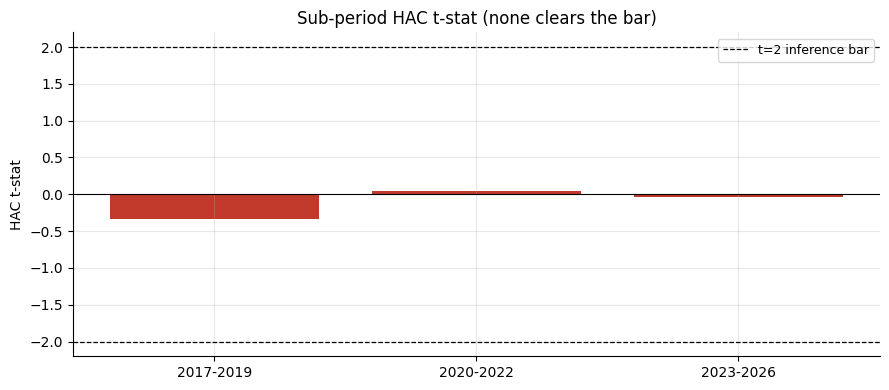

No sub-period reaches |t|=1, let alone 2. There is no signal to decay.


In [5]:
periods = [("2017-2019", "2017", "2019"), ("2020-2022", "2020", "2022"), ("2023-2026", "2023", "2026")]
sub_stats = []
for label, a, b in periods:
    sub = spread[a:b]
    s = st.summarize(sub)
    sub_stats.append({"period": label, "mean_ann": s["mean"]*1200, "tstat": s["tstat"], "n": s["n"]})
    print(f"  {label}: mean={s['mean']*1200:+.2f}%/yr  HAC t={s['tstat']:+.2f}  n={s['n']}")

sts = pd.DataFrame(sub_stats)
fig, ax = plt.subplots(figsize=(9, 4))
colors_sub = [GREEN if abs(t) >= 2 else RED for t in sts["tstat"]]
ax.bar(sts["period"], sts["tstat"], color=colors_sub)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2 inference bar")
ax.axhline(-2.0, color="black", ls="--", lw=0.9)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Sub-period HAC t-stat (none clears the bar)")
ax.set_ylabel("HAC t-stat"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("No sub-period reaches |t|=1, let alone 2. There is no signal to decay.")


## Turnover and cost drag: a negative number made worse

In [6]:
drag = st.turnover_cost_drag(sur, prices, q=0.20, one_way_bps=10.0)
avg_turnover = drag.mean() / 0.004
avg_drag = drag.mean() * 10000
net = spread - drag.reindex(spread.index).fillna(drag.mean())
s_net = st.summarize(net)
print(f"Avg monthly two-leg turnover: {avg_turnover:.2%}")
print(f"Avg drag @10bps one-way: {avg_drag:.1f} bps/mo")
print(f"Net spread @10bps: {s_net['mean']*1200:+.2f}%/yr = {s_net['mean']*10000:+.1f}bps/mo  HAC t={s_net['tstat']:+.2f}")
print()
print("> Honesty: the short (surge) leg ALSO pays stock-borrow on top of this, and the")
print("  gross spread is already negative -- costs only deepen the loss.")


Avg monthly two-leg turnover: 89.08%
Avg drag @10bps one-way: 35.6 bps/mo
Net spread @10bps: -5.49%/yr = -45.8bps/mo  HAC t=-1.39

> Honesty: the short (surge) leg ALSO pays stock-borrow on top of this, and the
  gross spread is already negative -- costs only deepen the loss.


## Random-portfolio null: no cross-sectional information

In [7]:
print("Computing random-portfolio null (n_draws=100 per month)...")
rand = st.random_portfolio_returns(sur, prices, q=0.20, n_draws=100, seed=253)
print(f"Random excess: mean={rand.mean()*10000:+.1f}bps  std={rand.std()*10000:.1f}bps")
print(f"  -> Null centred at zero: {abs(rand.mean()*10000) < 10}")
print("  -> The drought leg is statistically a random draw from the basket: the surge signal")
print("     carries no information beyond luck on this monthly mega-cap tape.")


Computing random-portfolio null (n_draws=100 per month)...


Random excess: mean=+0.7bps  std=250.1bps
  -> Null centred at zero: True
  -> The drought leg is statistically a random draw from the basket: the surge signal
     carries no information beyond luck on this monthly mega-cap tape.


## Verdict

In [8]:
print("=== Study 253 -- Wiki-Views ===")
print()
print(f"Signal: NONE   (drought-minus-surge HAC t = {R['spread_t']:+.2f}, CI [{R['boot_lo']:+.2f}, {R['boot_hi']:+.2f}] straddles zero)")
print(f"        Wrong sign, no sub-period clears |t|=1, random-null centred at zero.")
print(f"        Literature support (Moat 2013, Da-Engelberg-Gao 2011) alone never beats WEAK;")
print(f"        published effects are intraday-to-weekly small-cap, not monthly mega-cap.")
print()
print(f"Tradability: MIRAGE")
print(f"  Gross spread negative; turnover={R['turnover']:.0f}%/mo; net={R['net_spread_bps']:.1f}bps/mo before short-leg borrow.")
print()
print("Survivorship: NAMED -- basket = current mega-cap survivors; upper bound already zero.")
print()
print("Bottom line: None/Mirage -- a fun big-data folklore that does not survive as a")
print("  monthly cross-sectional signal on a liquid mega-cap basket.")


=== Study 253 -- Wiki-Views ===

Signal: NONE   (drought-minus-surge HAC t = -0.31, CI [-0.73, +0.54] straddles zero)
        Wrong sign, no sub-period clears |t|=1, random-null centred at zero.
        Literature support (Moat 2013, Da-Engelberg-Gao 2011) alone never beats WEAK;
        published effects are intraday-to-weekly small-cap, not monthly mega-cap.

Tradability: MIRAGE
  Gross spread negative; turnover=89%/mo; net=-45.8bps/mo before short-leg borrow.

Survivorship: NAMED -- basket = current mega-cap survivors; upper bound already zero.

Bottom line: None/Mirage -- a fun big-data folklore that does not survive as a
  monthly cross-sectional signal on a liquid mega-cap basket.
